# Risk Analysis - Artificial Neural Networks

# Load Data & Library

In [1]:
# --- SECTION 1: LOAD DATA & LIBRARY ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# Library Deep Learning (Artificial Neural Network)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Library Pendukung
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Inisialisasi Path
current_dir = os.getcwd()
path_file = os.path.join(current_dir, "..", "Data", "Processed", "ecommerce_clean.csv")

# Load Data
try:
    df = pd.read_csv(path_file)
    # Standarisasi nama kolom agar konsisten (Capitalize)
    df.columns = [col.strip().capitalize() for col in df.columns]
    print("✅ Berhasil memuat data!")
    
    # Menampilkan daftar kolom yang tersedia
    print("\nKolom yang tersedia di Dataframe:")
    print(df.columns.tolist())
    
    # Menampilkan 5 data teratas
    display(df.head())
    
except Exception as e:
    print(f"❌ Gagal memuat data! Periksa apakah file ada di {path_file}")
    print(f"Error: {e}")

ModuleNotFoundError: No module named 'tensorflow'

# Labeling

In [3]:
# --- SECTION 2: LABELING ---

# 1. Menghitung Profit Margin
# Menggunakan .get() agar aman jika kolom salah tulis
if 'Profit' in df.columns and 'Sales' in df.columns:
    df['Margin'] = df['Profit'] / df['Sales']
    
    # 2. Menentukan Threshold Risiko (15% margin terendah)
    threshold = df['Margin'].quantile(0.15)
    
    # 3. Membuat kolom target 'Is_risk'
    # 1: Risiko (Margin <= threshold), 0: Aman
    df['Is_risk'] = (df['Margin'] <= threshold).astype(int)
    
    print("\n✅ Labeling Selesai!")
    print(f"Threshold Margin untuk Risiko: {threshold:.2%}")
    print("-" * 30)
    print("Distribusi Kelas (Is_risk):")
    print(df['Is_risk'].value_counts())
    print("-" * 30)
else:
    print("❌ Kolom 'Profit' atau 'Sales' tidak ditemukan untuk proses labeling.")


✅ Labeling Selesai!
Threshold Margin untuk Risiko: 8.02%
------------------------------
Distribusi Kelas (Is_risk):
Is_risk
0    4250
1     750
Name: count, dtype: int64
------------------------------


# Data Preparation

In [4]:
# --- SECTION 3: DATA PREPARATION ---

# 1. Memilih Fitur yang Akan Digunakan
# Kita gunakan fitur yang sama dengan model sebelumnya agar komparasi adil
features_list = ['Region', 'Category', 'Discount', 'Quantity', 'Unit price']
X = df[[col for col in features_list if col in df.columns]]
y = df['Is_risk']

# 2. One-Hot Encoding untuk Variabel Kategorikal
# ANN memerlukan input berupa angka murni
X_encoded = pd.get_dummies(X, columns=['Region', 'Category'], drop_first=True)

# 3. Membagi Data (Train & Test Split)
# Kita gunakan stratify agar distribusi kelas risiko seimbang di kedua dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling (Wajib untuk ANN)
# StandardScaler mengubah data sehingga rata-rata = 0 dan standar deviasi = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Persiapan Data Selesai!")
print(f"Jumlah Fitur setelah Encoding: {X_train_scaled.shape[1]}")
print(f"Ukuran Data Train: {X_train_scaled.shape[0]} baris")
print(f"Ukuran Data Test : {X_test_scaled.shape[0]} baris")

✅ Persiapan Data Selesai!
Jumlah Fitur setelah Encoding: 14
Ukuran Data Train: 4000 baris
Ukuran Data Test : 1000 baris


# Model Training

In [7]:
# --- SECTION 4: MODEL TRAINING (ANN DENGAN CLASS WEIGHT) ---

from sklearn.utils import class_weight

# 1. Menangani Imbalance Data dengan Class Weight
# Ini memastikan model memberikan perhatian lebih pada kelas 'Risiko' (1)
weights = class_weight.compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
dict_weights = {0: weights[0], 1: weights[1]}

# 2. Membangun Arsitektur Model
model = Sequential([
    # Input Layer & First Hidden Layer
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), 
    
    # Second Hidden Layer
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    # Output Layer (Sigmoid untuk Klasifikasi Biner)
    Dense(1, activation='sigmoid')
])

# 3. Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Early Stopping
# Berhenti jika val_loss tidak membaik dalam 10 kali percobaan
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# 5. Proses Training
print("Sedang melatih Yapay Sinir Ağları (ANN) dengan Class Weight...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=dict_weights, # <--- Menerapkan bobot kelas
    verbose=1
)

print("\n✅ Training Selesai dengan Perbaikan Class Weight!")

Sedang melatih Yapay Sinir Ağları (ANN) dengan Class Weight...
Epoch 1/100


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4669 - loss: 0.7494 - val_accuracy: 0.4988 - val_loss: 0.6968
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4647 - loss: 0.7273 - val_accuracy: 0.4613 - val_loss: 0.7115
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4869 - loss: 0.7110 - val_accuracy: 0.4563 - val_loss: 0.7081
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4663 - loss: 0.7115 - val_accuracy: 0.4812 - val_loss: 0.6998
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4922 - loss: 0.7013 - val_accuracy: 0.5300 - val_loss: 0.6929
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - loss: 0.7038 - val_accuracy: 0.4712 - val_loss: 0.7003
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4681 - loss: 0.6982 - val_accuracy: 0.4825 - val_loss: 0.6977
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5006 - loss: 0.6964 - val_accuracy: 0.4825

# EVALUATION

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


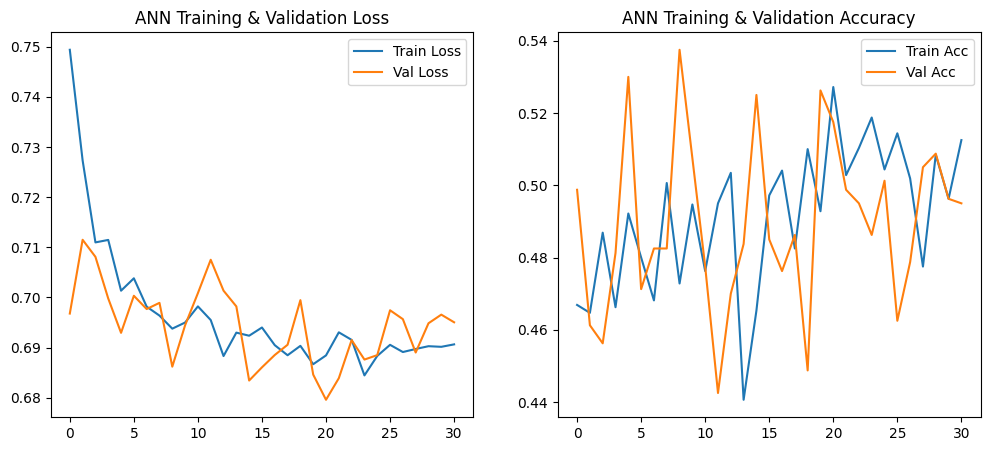


[ Laporan Klasifikasi: Yapay Sinir Ağları (ANN) ]
              precision    recall  f1-score   support

           0       0.87      0.48      0.62       850
           1       0.16      0.58      0.26       150

    accuracy                           0.49      1000
   macro avg       0.51      0.53      0.44      1000
weighted avg       0.76      0.49      0.56      1000



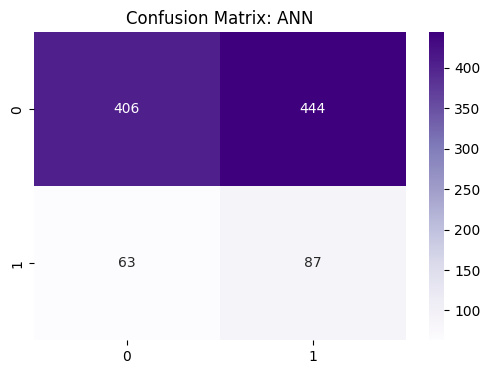

In [8]:
# --- SECTION 5: EVALUATION (ANN) ---

# 1. Prediksi pada data test
# Karena output ANN adalah probabilitas (0-1), kita bulatkan: >0.5 jadi 1, sisanya 0
y_pred_prob = model.predict(X_test_scaled)
y_pred_ann = (y_pred_prob > 0.5).astype(int)

# 2. Visualisasi History Training (Loss & Accuracy)
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN Training & Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('ANN Training & Validation Accuracy')
plt.legend()

plt.show()

# 3. Print Laporan Klasifikasi
print("\n[ Laporan Klasifikasi: Yapay Sinir Ağları (ANN) ]")
print(classification_report(y_test, y_pred_ann))

# 4. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_ann), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: ANN')
plt.show()

# Save Model

In [9]:
# --- SECTION 6: SAVE MODEL (ANN) ---

# 1. Simpan Model ANN (Format Keras)
model.save('model_risiko_ann.h5')

# 2. Simpan Scaler (Wajib untuk preprocessing di Streamlit nanti)
joblib.dump(scaler, 'scaler_risiko_ann.pkl')

# 3. Simpan Daftar Fitur (Urutan kolom setelah Encoding)
joblib.dump(X_train.columns.tolist(), 'features_ann.pkl')

print("✅ Berhasil!")
print("1. Model ANN disimpan sebagai: model_risiko_ann.h5")
print("2. Scaler disimpan sebagai: scaler_risiko_ann.pkl")
print("3. Daftar fitur disimpan sebagai: features_ann.pkl")

✅ Berhasil!
1. Model ANN disimpan sebagai: model_risiko_ann.h5
2. Scaler disimpan sebagai: scaler_risiko_ann.pkl
3. Daftar fitur disimpan sebagai: features_ann.pkl
